# Assignment 1

Note: This notebook file for the assignment has deviations from the course guide with respect to the structure, sentence framing, question framing and numbering. Please consider this notebook file structure as the final structure and follow this.

In this assignment, you will explore the CIFAR10 dataset. 

You have to download the dataset from Pytorch.

Comment your code and indicate what the different instructions are doing and what you are showing and printing. 
When printing figures do not forget about the title, x and y labels. The font size should be matching the text size of the text in your report. 
Do not forget to add legends to the plots. 

------------------------

In [2]:
# Load all the needed packages for this assignment here
import matplotlib.pyplot as plt
import numpy as np

#### Exercise 1.1 - Load data

**a)** Load the CIFAR10 dataset. 

**b)** Print the number of samples and the number of classes present in the dataset. 

**c)** Also print the shape of an image in the dataset. 

In [3]:
# Ex.1.1a,b & c
import torchvision
from torchvision import datasets

dataset = datasets.CIFAR10(root="./data", train=True, download=True)

print("\nb) Information about the dataset:")
print(dataset)

print("Number of samples: " + str(len(dataset)))
print("Names of classes: " + str(dataset.classes))
print("Number of classes: " + str(len(dataset.classes)))

print("\nc) Shape of the first image:")
print(dataset.data[0].shape)


c:\Data\assignmentsDS\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



b) Information about the dataset:
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
Number of samples: 50000
Names of classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10

c) Shape of the first image:
(32, 32, 3)


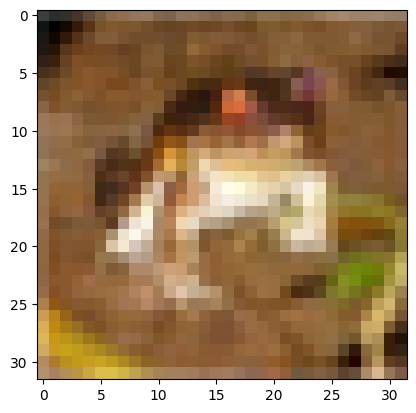

Label of the image: frog


In [4]:
img, label = dataset[0]
plt.imshow(img)
plt.show()
print("Label of the image: " + str(dataset.classes[label]))

#### Exercise 1.2 - Quantify dataset

**a)** Print the number of samples per category.

In [5]:
# Ex.1.2a your code here

# see https://stackoverflow.com/questions/62266514/number-of-images-per-class-in-dataset-pytorch

num_classes = len(dataset.classes)
label_dict = {}

for i in range(num_classes):
    label_dict[dataset.classes[i]] = 0

for i in range(len(dataset)):
    img, label = dataset[i]
    label_dict[dataset.classes[label]] += 1

print(label_dict)

{'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


**b)** Plot the number of samples per category using a bar plot.

<BarContainer object of 10 artists>

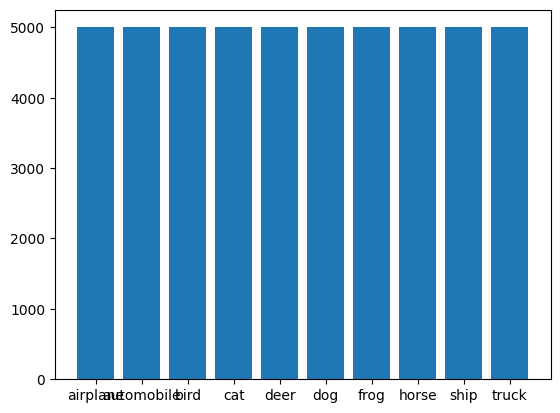

In [6]:
plt.bar(label_dict.keys(), label_dict.values())

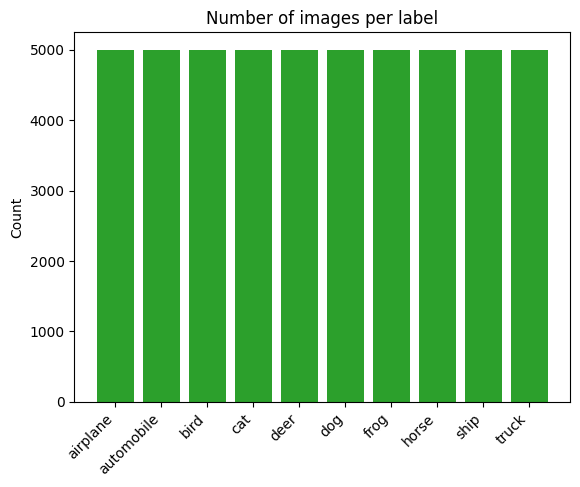

In [7]:
# Ex.1.2b your code here

fig, ax = plt.subplots()

labels = label_dict.keys()
counts = label_dict.values()
bar_colors = ['tab:green']

ax.bar(labels, counts, label=labels, color=bar_colors)

plt.xticks(rotation=45, ha='right')

ax.set_ylabel('Count')
ax.set_title('Number of images per label')

plt.show()

**Reflection: Answer the below question**

Are you working with a balanced or an unbalanced dataset? Are there majoritarian classes? Do you think this will affect the later analysis and training of your models?

> Your Answer (Double click to edit): Balanced, no majoritarian class! It will affect the later analysis and training positively, as there is no class bias for training.

#### Exercise 1.3 - Visualize images in your dataset

Create a figure with n x 4 sub-plots. The value of 'n' depends on the number of categories present in the dataset.
As the title of each row in your figure, indicate the category it belongs to.

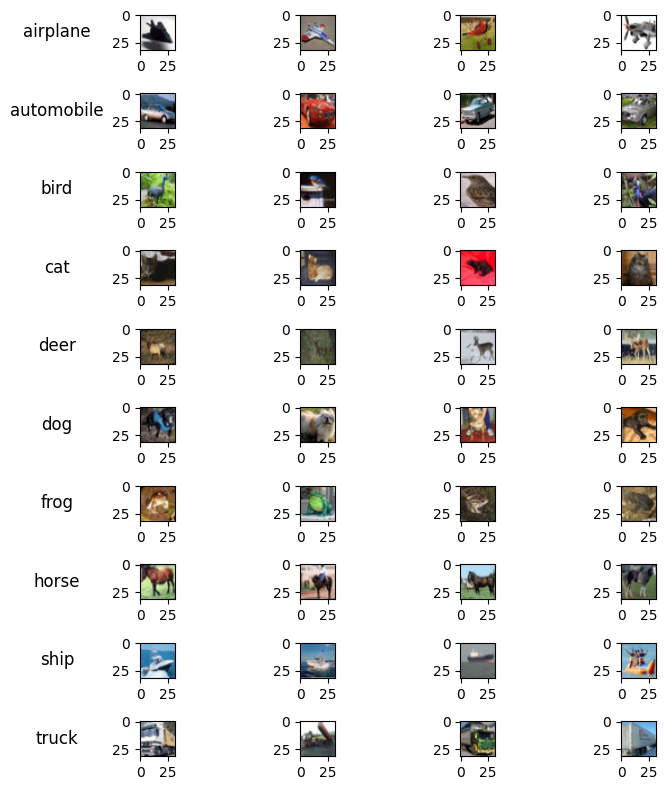

In [ ]:
# Ex.1.3 your code here

import seaborn as sns

# tuple = str('ax') + str(range(10))
# print(tuple)

fig, axes = plt.subplots(ncols=4, nrows=10, figsize=(8,8))
rows = dataset.classes

samples = []

for ax, row in zip(axes[:,0], rows):
    ax.set_ylabel(row, rotation=0, labelpad=40, fontsize=12, va='center')
    index = 0
    for img, label in dataset:
        if dataset.classes[label]==row:
            axes[label, index].imshow(img)
            samples.append(img)
            index += 1
            if index == 4:
                break
   
fig.tight_layout()
plt.show()



#### Exercise 1.4 - RGB feature extraction

Extract RGB values from each image in your dataset as three seperate lists(one per channel). Each list should have 8 values. To do so, you can compute the histogram of each channel with 8 bins. Then you have to concatenate the values of all the three channels together resulting in a feature vector of size 24. This feature vector is the descriptor of an image in your dataset. You will have to do this for all the images present in your dataset in order to get the overall RGB descriptor which will be of size (n,24). Here 'n' depends on the number of samples present in the dataset. 

In [ ]:
# Ex.1.4 your code here

r_chanel = np.zeros(8)
g_chanel = np.zeros(8)
b_chanel = np.zeros(8)

dict_rgb = {}

for i in range(len(dataset)):

    r_chanel = np.histogram(dataset.data[i][:,:,0], bins=8)
    g_chanel = np.histogram(dataset.data[i][:,:,1], bins=8)
    b_chanel = np.histogram(dataset.data[i][:,:,2], bins=8)

    vec = np.concatenate((r_chanel[0], g_chanel[0], b_chanel[0]))

    label = dataset[i][1]

    dict_rgb[i] = (vec, dataset.classes[label])
    
print(dict_rgb)

{0: (array([  5,  28,  64, 242, 444, 117,  77,  47,  23,  92, 365, 320, 105,
        60,  38,  21, 123, 477, 242,  86,  32,  30,  20,  14]), 'frog'), 1: (array([ 47, 125, 212, 160, 131, 133, 130,  86,  48, 121, 190, 169, 164,
       160,  74,  98,  46, 125, 180, 157, 214, 123,  87,  92]), 'truck'), 2: (array([134, 315, 111,  75,  46,  22,  31, 290, 129, 214, 217,  73,  45,
        27,  28, 291, 113, 250, 236,  70,  22,  23,  28, 282]), 'truck'), 3: (array([ 39, 115, 437, 265,  82,  24,  22,  40,  51, 135, 472, 244,  47,
        27,  22,  26,  58, 208, 515, 146,  32,  31,  30,   4]), 'deer'), 4: (array([125, 256, 306,  70,  71, 121,  34,  41, 118,  76, 303, 233,  65,
       134,  68,  27, 121,  75, 184, 223, 151,  64, 123,  83]), 'automobile'), 5: (array([ 44, 117, 151, 154, 182, 130, 142, 104, 218, 280, 220, 170,  91,
        32,   6,   7, 281, 317, 215, 111,  65,  22,   8,   5]), 'automobile'), 6: (array([ 21,  57, 126, 204, 210, 168, 158,  80,  17,  60,  98, 188, 209,
       191, 197

#### Exercise 1.5 - Compute the inter-class variability of your dataset.

Inter-class correlation aims at understanding the relationship/correlation among the classes/categories present in your dataset. For this, you could compute a measure (for example mean, std etc.) collectively for all the samples belonging to each and every class of the dataset. Then you could make use of this measure to find the correlation among the classes/categories using the standard pandas dataframe correlation function. Link: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

            airplane  automobile      bird       cat      deer       dog  \
airplane    1.000000   -0.458769 -0.022731 -0.605745 -0.368947 -0.640787   
automobile -0.458769    1.000000  0.603578  0.863891  0.663145  0.741709   
bird       -0.022731    0.603578  1.000000  0.672244  0.907720  0.712291   
cat        -0.605745    0.863891  0.672244  1.000000  0.746302  0.953113   
deer       -0.368947    0.663145  0.907720  0.746302  1.000000  0.837078   
dog        -0.640787    0.741709  0.712291  0.953113  0.837078  1.000000   
frog       -0.462799    0.790260  0.872678  0.889522  0.960370  0.934983   
horse      -0.411589    0.838208  0.848319  0.944875  0.859313  0.918482   
ship        0.736109   -0.165240  0.323072 -0.386388  0.139698 -0.327025   
truck       0.002055    0.840047  0.619573  0.671875  0.490907  0.491149   

                frog     horse      ship     truck  
airplane   -0.462799 -0.411589  0.736109  0.002055  
automobile  0.790260  0.838208 -0.165240  0.840047  
bird

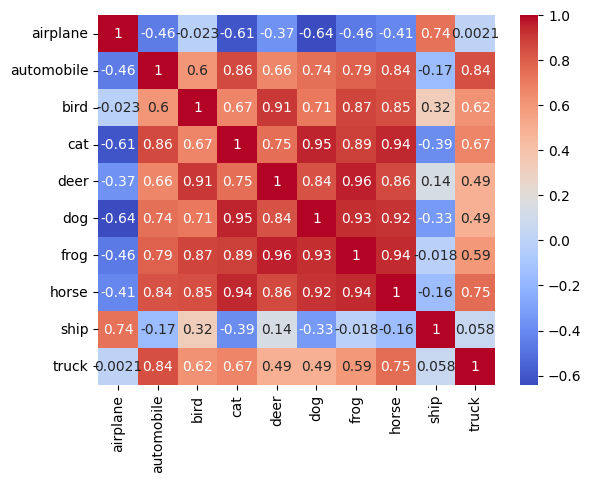

In [32]:
# Ex.1.5 your code here
import pandas as pd

class_means = {'airplane': np.zeros(24), 'automobile': np.zeros(24), 'bird': np.zeros(24), 'cat': np.zeros(24), 'deer': np.zeros(24), 'dog': np.zeros(24), 'frog': np.zeros(24), 'horse': np.zeros(24), 'ship': np.zeros(24), 'truck': np.zeros(24)}

for value in dict_rgb.values():
    label = value[1]
    vec = value[0]

    class_means[label] += vec

class_means = {key: value/5000 for key, value in class_means.items()}

# print(class_means)

df = pd.DataFrame(class_means)
df

# df.corr(method='pearson')
correlation = df.corr(method='pearson')
sns.heatmap(correlation, annot=True, cmap='coolwarm')

print(correlation)


**c)** Compute the Silhouette score. 

The Silhouette score is used to assess the performance of using unsupervised machine learning (clustering). We can also use it here to assess the compactness of the extracted descriptors per category and for the group of categories as their mean.

You can use the function available in Sklearn - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

In [35]:
# Ex.1.5c your code here

import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=10)
silhouette_score(df, kmeans.fit_predict(df))

0.37699707280978884

**Reflection: (Answer the below questions)** 

**1.** Does Intra-class correlation score/coefficient help you assess the degree of similarity among the samples of a category?
> Yes, it measures the similarity of the samples within clusters (our classes), whereas 0 = not similar at all, 1 = identical. 

**2.** What can you deduce from the Inter-class correlation and Silhouette score?
> Inter-class correlation shows the similarity between classes. Our silhouette score is around 0.35 - so not that great. However, this value can be explained by the use of RGB values - the colors are not a very good descriptor of a class. E.g. some frog pictures are more red-ish, while others can be more green-ish etc. Two classes can have a similiar hue in color. This is also evident from the correlation heatmap, which shows the Inter-class correlations.

#### Exercise 1.6 - Dimensionality reduction for visualization 

We can visualize large datasets having higher dimensions or features in 2- or 3-dimensional spaces. For this, you need to reduce the dimensionality of the data. 

In this exercise, you are asked to use PCA for reducing dimensionality.

Link to function to apply PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Create the following two figures:

**a)** Rely on the first 2 principal components to plot the samples of your dataset. Use one color per class.

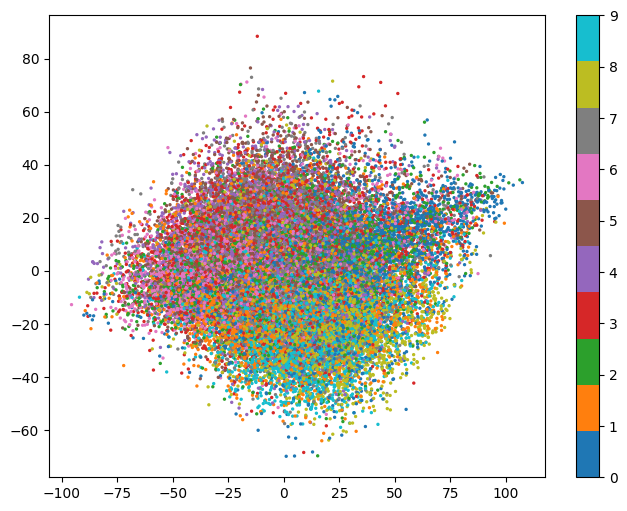

In [69]:
# Ex.1.6a your code here
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


X = dataset.data
X = X.reshape(X.shape[0], -1)
y = dataset.targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap="tab10",
    s=2
)

plt.colorbar(scatter)
plt.show()


**b)** Rely on the first 3 principal components to create a 3D plot. Use one color per class.

C:\Users\klkle\AppData\Local\Temp\ipykernel_19188\1822881154.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


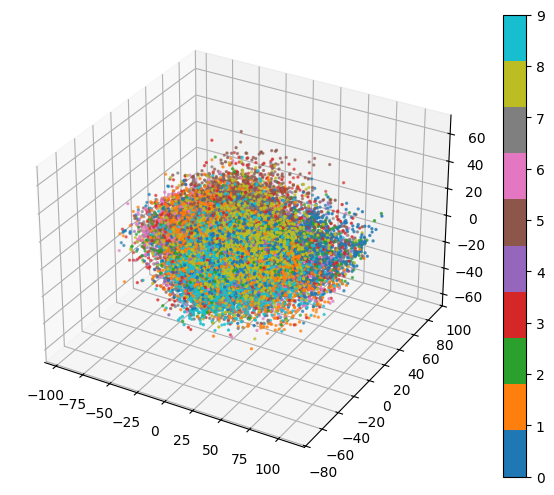

In [70]:
# Ex.1.6b your code here

X = dataset.data
X = X.reshape(X.shape[0], -1)
y = dataset.targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

pca = PCA(n_components=3)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train[:,0],
    X_train[:,1],
    X_train[:,2],
    c=y_train,
    cmap="tab10",
    s=2
)

fig.colorbar(scatter)
fig.show()


#### Exercise 1.7 - Reflection

Reflect on the following questions.

**a)** Will you obtain the same visualisation in the feature space for different extracted features?
> No. Features will show different feature spaces, for example RGB descriptors, edges, spacial resolution, intensity,...
    
**b)** Are the classes distinguishable on the feature space when relying on PCA over RGB?
> Not really, in PCA they overlap a lot. The diagram/ clusters are hard to read and differenciate. But there are some trends visible. The RGB correlation heatmap is easier to interpret, but seeing the silhuette score the RGB describtor is probably not the best approach. 
    
**c)** What other visualization could you include to better describe your data?
> - Histograms of the RGB means for each class. 
- For PCA we can use the explained variance and plot each component and how much of the total variance in the dataset it can explain respectively. 

#### [Optional] Exercise: Repeat experiments with different image descriptors

e.g. 
- Harris Corner Detection

- Shi-Tomasi Corner Detector and Good Features to Track

- Scale-Invariant Feature Transform (SIFT)

- Speeded-up robust features (SURF)

- Features from Accelerated Segment Test (FAST)

- Blob Detectors With LoG, DoG, and DoH

If you have OpenCV installed you can follow this example,
https://automaticaddison.com/image-feature-detection-description-and-matching-in-opencv/

When using Scikit-image,
https://scikit-image.org/docs/dev/api/skimage.feature.html?highlight=hog